# 05 - Grad-CAM : Interpretabilite du Modele
Visualisation des zones utilisees par le CNN pour la classification

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import cv2
from PIL import Image

In [2]:
# Configuration
DATA_DIR = Path('../data/chest_xray')
MODEL_PATH = Path('../outputs/checkpoints/best_resnet18.pt')
IMG_SIZE = 224

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


## 1. Charger le modele ResNet18

In [3]:
# Recreer l'architecture ResNet18 (SANS Sigmoid)
model = models.resnet18(weights=None)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1)
    # Pas de Sigmoid - on utilise BCEWithLogitsLoss
)

# Charger les poids
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model = model.to(device)
model.eval()
print("Modele charge!")

Modele charge!


In [4]:
# Charger le test set
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(DATA_DIR / 'test', transform=test_transform)
print(f"Test set: {len(test_dataset)} images")
print(f"Classes: {test_dataset.classes}")

Test set: 624 images
Classes: ['NORMAL', 'PNEUMONIA']


## 2. Implementation de Grad-CAM

In [5]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hook pour capturer les gradients et activations
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_tensor, target_class=None):
        # Forward pass
        self.model.zero_grad()
        output = self.model(input_tensor)  # Logits
        
        # Backward pass
        output.backward()
        
        # Calculer les poids (moyenne globale des gradients)
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        
        # Calculer la heatmap
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)
        cam = torch.relu(cam)  # ReLU pour garder les activations positives
        
        # Normaliser
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        
        # Appliquer sigmoid pour obtenir la probabilite
        prob = torch.sigmoid(output).item()
        
        return cam.squeeze().cpu().numpy(), prob

In [6]:
# Initialiser Grad-CAM sur la derniere couche conv de ResNet18 (layer4)
target_layer = model.layer4[-1].conv2
grad_cam = GradCAM(model, target_layer)
print("Grad-CAM initialise sur layer4")

Grad-CAM initialise sur layer4


## 3. Fonction de visualisation

In [7]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

def visualize_gradcam(model, grad_cam, dataset, idx, device):
    # Charger l'image
    img_tensor, label = dataset[idx]
    img_tensor = img_tensor.unsqueeze(0).to(device)
    img_tensor.requires_grad = True
    
    # Generer la heatmap
    heatmap, prob = grad_cam.generate_cam(img_tensor)
    
    # Redimensionner la heatmap
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    
    # Image originale
    img_display = denormalize(img_tensor.squeeze().cpu().detach())
    img_display = img_display.permute(1, 2, 0).numpy()
    img_display = np.clip(img_display, 0, 1)
    
    # Creer la superposition
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
    
    superimposed = 0.5 * img_display + 0.5 * heatmap_colored
    superimposed = np.clip(superimposed, 0, 1)
    
    # Labels
    class_names = ['NORMAL', 'PNEUMONIA']
    true_label = class_names[label]
    pred_label = class_names[1] if prob > 0.5 else class_names[0]
    
    return img_display, heatmap_resized, superimposed, true_label, pred_label, prob

## 4. Visualiser des exemples PNEUMONIA

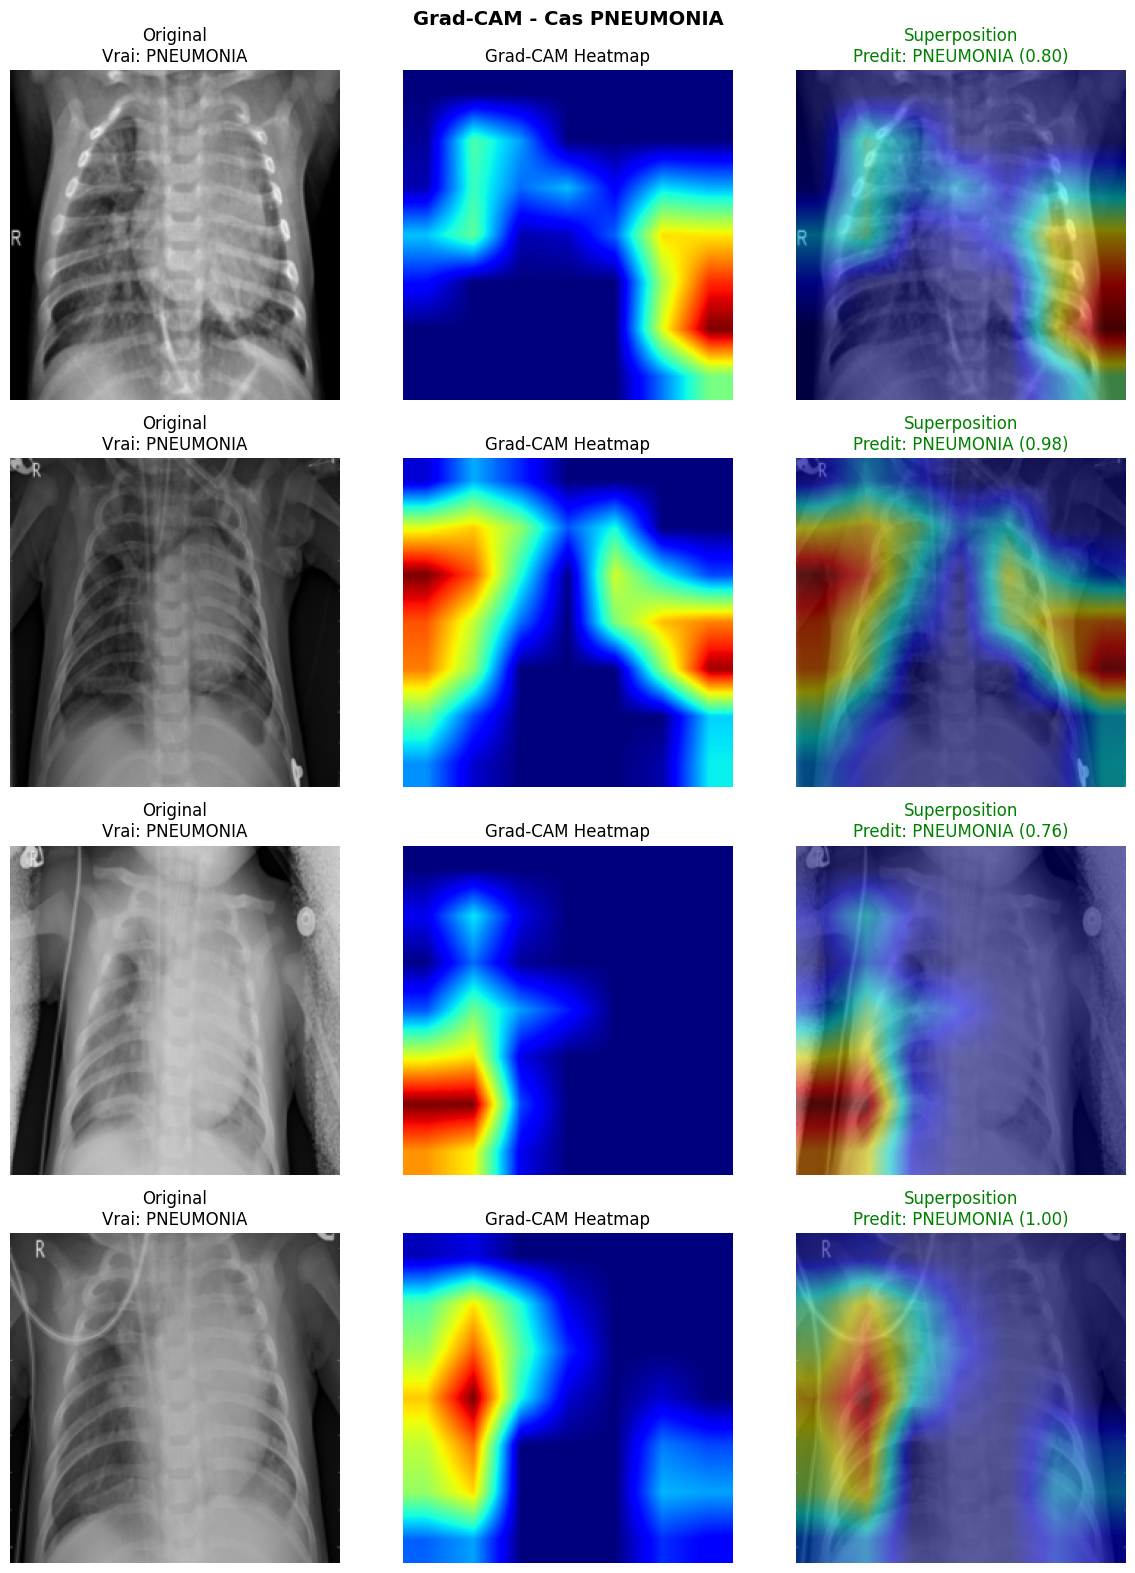

In [8]:
# Trouver des indices de PNEUMONIA
pneumonia_indices = [i for i, (_, label) in enumerate(test_dataset) if label == 1][:4]

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for row, idx in enumerate(pneumonia_indices):
    img, heatmap, superimposed, true_label, pred_label, prob = visualize_gradcam(
        model, grad_cam, test_dataset, idx, device
    )
    
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f'Original\nVrai: {true_label}')
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(heatmap, cmap='jet')
    axes[row, 1].set_title('Grad-CAM Heatmap')
    axes[row, 1].axis('off')
    
    color = 'green' if pred_label == true_label else 'red'
    axes[row, 2].imshow(superimposed)
    axes[row, 2].set_title(f'Superposition\nPredit: {pred_label} ({prob:.2f})', color=color)
    axes[row, 2].axis('off')

plt.suptitle('Grad-CAM - Cas PNEUMONIA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/gradcam_pneumonia.png', dpi=150)
plt.show()

## 5. Visualiser des exemples NORMAL

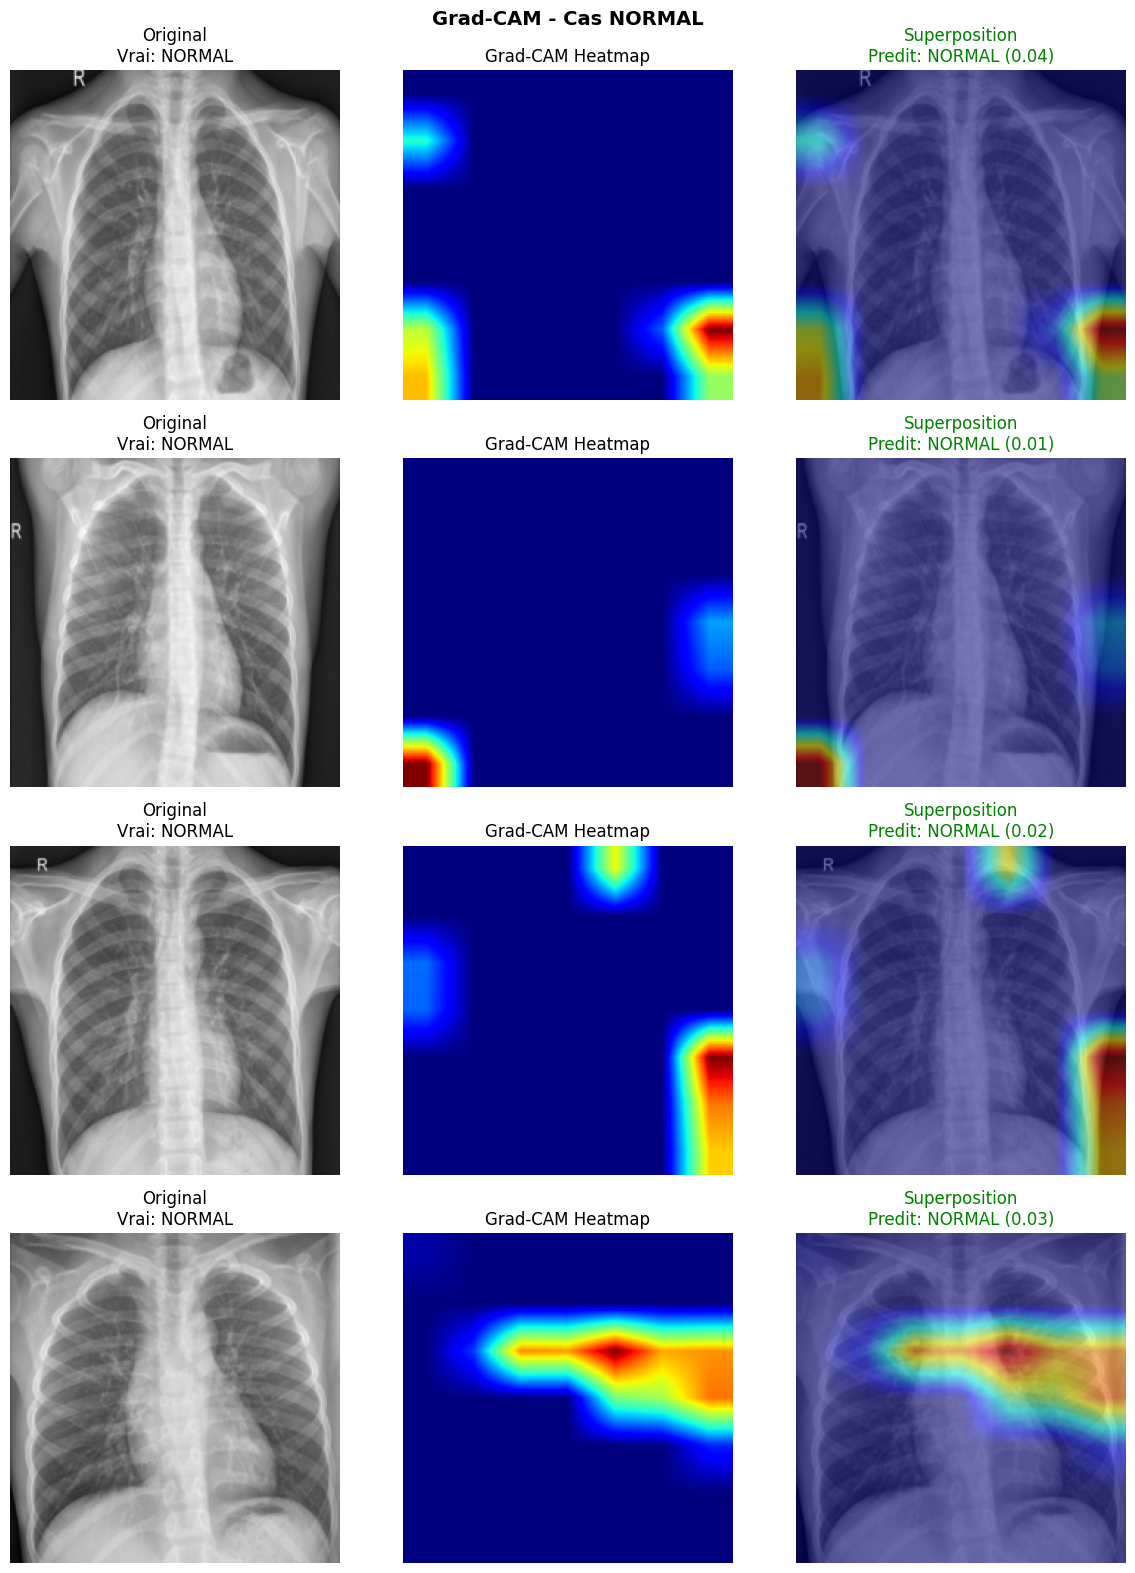

In [9]:
# Trouver des indices de NORMAL
normal_indices = [i for i, (_, label) in enumerate(test_dataset) if label == 0][:4]

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for row, idx in enumerate(normal_indices):
    img, heatmap, superimposed, true_label, pred_label, prob = visualize_gradcam(
        model, grad_cam, test_dataset, idx, device
    )
    
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f'Original\nVrai: {true_label}')
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(heatmap, cmap='jet')
    axes[row, 1].set_title('Grad-CAM Heatmap')
    axes[row, 1].axis('off')
    
    color = 'green' if pred_label == true_label else 'red'
    axes[row, 2].imshow(superimposed)
    axes[row, 2].set_title(f'Superposition\nPredit: {pred_label} ({prob:.2f})', color=color)
    axes[row, 2].axis('off')

plt.suptitle('Grad-CAM - Cas NORMAL', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/gradcam_normal.png', dpi=150)
plt.show()

## 6. Analyser les erreurs avec Grad-CAM

In [10]:
# Trouver les faux negatifs (PNEUMONIA classee NORMAL)
false_negatives = []
false_positives = []

model.eval()
with torch.no_grad():
    for idx in range(len(test_dataset)):
        img, label = test_dataset[idx]
        img = img.unsqueeze(0).to(device)
        logit = model(img)
        prob = torch.sigmoid(logit).item()  # Convertir logit en probabilite
        pred = 1 if prob > 0.5 else 0
        
        if pred == 0 and label == 1:  # Faux negatif
            false_negatives.append(idx)
        elif pred == 1 and label == 0:  # Faux positif
            false_positives.append(idx)

print(f"Faux Negatifs: {len(false_negatives)}")
print(f"Faux Positifs: {len(false_positives)}")

Faux Negatifs: 24
Faux Positifs: 32


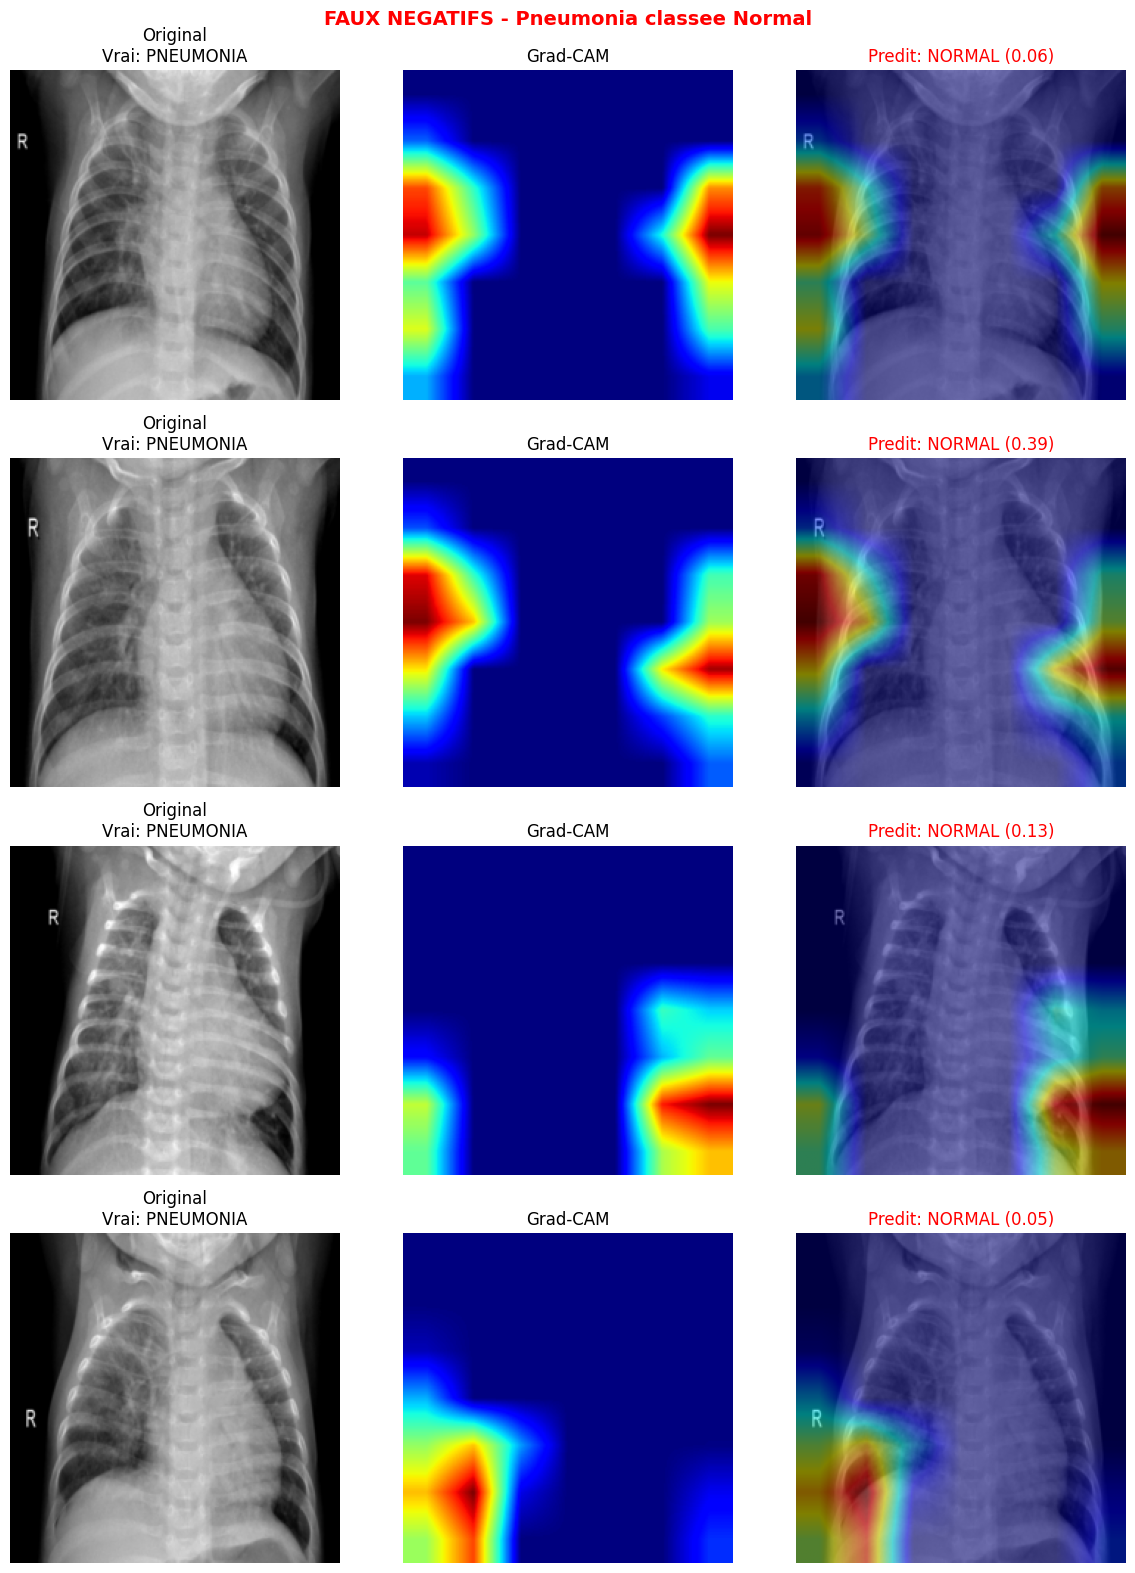

In [11]:
# Visualiser quelques faux negatifs
if len(false_negatives) > 0:
    n_show = min(4, len(false_negatives))
    fig, axes = plt.subplots(n_show, 3, figsize=(12, 4*n_show))
    if n_show == 1:
        axes = axes.reshape(1, -1)
    
    for row, idx in enumerate(false_negatives[:n_show]):
        img, heatmap, superimposed, true_label, pred_label, prob = visualize_gradcam(
            model, grad_cam, test_dataset, idx, device
        )
        
        axes[row, 0].imshow(img)
        axes[row, 0].set_title(f'Original\nVrai: {true_label}')
        axes[row, 0].axis('off')
        
        axes[row, 1].imshow(heatmap, cmap='jet')
        axes[row, 1].set_title('Grad-CAM')
        axes[row, 1].axis('off')
        
        axes[row, 2].imshow(superimposed)
        axes[row, 2].set_title(f'Predit: {pred_label} ({prob:.2f})', color='red')
        axes[row, 2].axis('off')
    
    plt.suptitle('FAUX NEGATIFS - Pneumonia classee Normal', fontsize=14, fontweight='bold', color='red')
    plt.tight_layout()
    plt.savefig('../outputs/figures/gradcam_false_negatives.png', dpi=150)
    plt.show()
else:
    print("Aucun faux negatif!")

## Resume

### Grad-CAM permet de:
1. **Visualiser** les zones de l'image utilisees pour la prediction
2. **Verifier** que le modele regarde les bonnes regions (poumons)
3. **Comprendre** pourquoi le modele fait des erreurs
4. **Augmenter la confiance** dans les predictions du modele

### Interpretation:
- Les zones **rouges/jaunes** sont les plus importantes pour la decision
- Pour PNEUMONIA, on s'attend a voir les zones infectees des poumons
- Pour NORMAL, l'activation devrait etre plus diffuse

### Figures sauvegardees:
- `gradcam_pneumonia.png`
- `gradcam_normal.png`
- `gradcam_false_negatives.png`